In [ ]:
# !pip install -r requirements.txt

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
!pip install mxnet
!pip install gluonnlp pandas tqdm
!pip install sentencepiece==0.1.91
!pip install transformers==4.8.2
!pip install torch
!pip install 'git+https://github.com/SKTBrain/KoBERT.git#egg=kobert_tokenizer&subdirectory=kobert_hf'

!pip uninstall numpy
!pip install numpy==1.23.1


In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

### 데이터 확인


In [2]:
path = '/content/drive/MyDrive/대학원/영화/'

df_movie = pd.read_pickle(path+'movie_reviews.pkl')
df_info = pd.read_pickle(path+'movie_info.pkl')

df = df_movie[['movieNm', 'movieCd', 'review', '별점', '추천', '반대', '작성일']]
df = df.rename(columns={'별점' : 'target'})
df1 = df_info[['movieNm', 'movieCd', '영화유형', '국적', '전국 매출액', '전국 관객수', '장르', '등급', '영화구분']]

df_m = df.merge(df1, on=['movieNm'], how='inner')
# 다중공백 제거
df_m['review'] = df_m['review'].str.replace(" +", " ") # 다중 공백 제거
df_m.shape

(68877, 15)

In [3]:
# 불용어
!wget https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
with open('korean_stopwords.txt', 'r') as f:
    stop_words = f.read().split("\n")
print(len(stop_words), stop_words[:10])
stop_words = ['는', '두']+stop_words
print(len(stop_words), stop_words[:10])

--2024-04-24 16:16:59--  https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7007 (6.8K) [text/plain]
Saving to: ‘korean_stopwords.txt.2’

korean_stopwords.tx 100%[===================>]   6.84K  --.-KB/s    in 0s      

2024-04-24 16:17:00 (95.9 MB/s) - ‘korean_stopwords.txt.2’ saved [7007/7007]

675 ['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라']
677 ['는', '두', '아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리']


In [4]:
df_m['장르'].unique()

array(['멜로/로맨스', '드라마', nan, '공연', '다큐멘터리', '코미디', '판타지', '액션', '애니메이션',
       'SF', '공포(호러)', '미스터리', '범죄', '전쟁', '사극', '스릴러', '가족', '기타',
       '어드벤처', '뮤지컬', '서부극(웨스턴)'], dtype=object)

<Axes: >

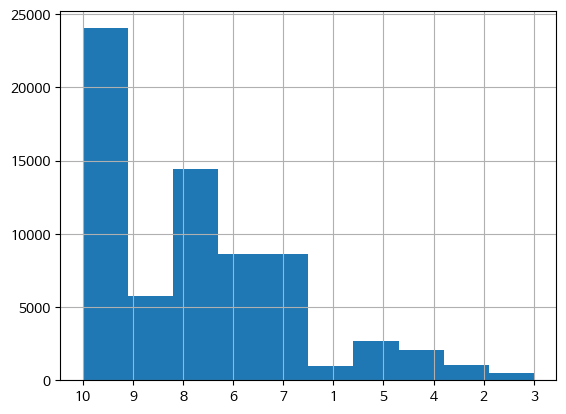

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

df_m['target'].hist()

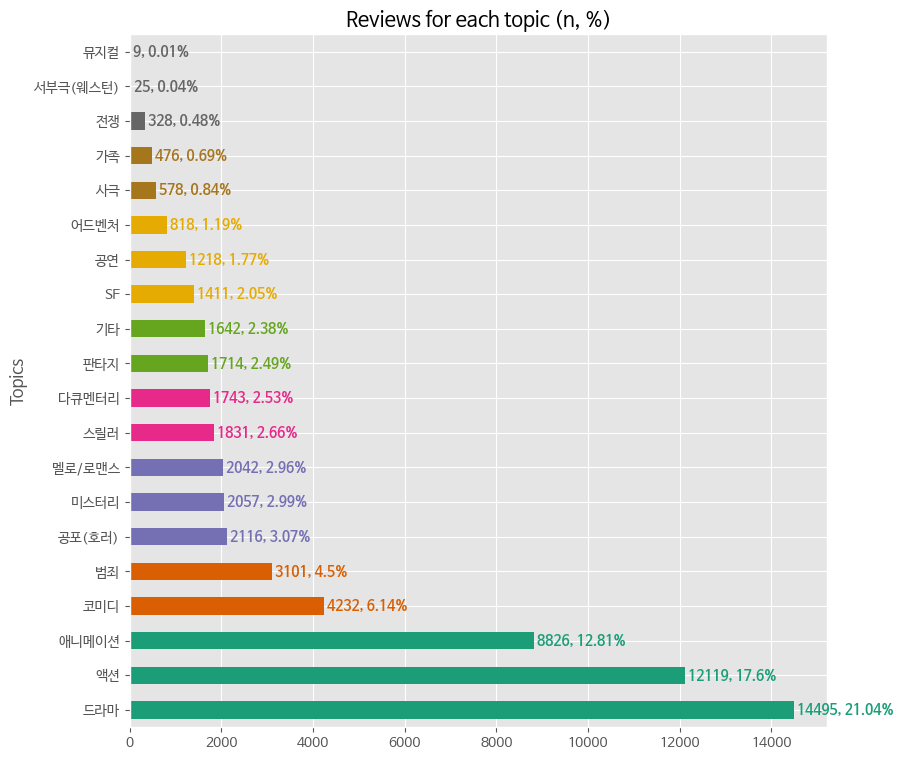

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')


num_classes = len(df_m["장르"].value_counts())

colors = plt.cm.Dark2(np.linspace(0, 1, num_classes))
iter_color = iter(colors)

df_m['장르'].value_counts().plot.barh(title="Reviews for each topic (n, %)",
                                                 ylabel="Topics",
                                                 color=colors,
                                                 figsize=(9,9))

for i, v in enumerate(df_m['장르'].value_counts()):
  c = next(iter_color)
  plt.text(v, i,
           " "+str(v)+", "+str(round(v*100/df.shape[0],2))+"%",
           color=c,
           va='center',
           fontweight='bold')

In [7]:
df_m.head(2)

,movieNm,movieCd_x,review,target,추천,반대,작성일,movieCd_y,영화유형,국적,전국 매출액,전국 관객수,장르,등급,영화구분
0,10일간의 애인,NaN,기대를 져버리지 않는 송민경,10,21,2,2023.01.12. 13:59,NaN,개봉영화,한국,21160996,2118,멜로/로맨스,청소년관람불가,일반영화
1,10일간의 애인,NaN,연출이랑 편집이 급하게 처리한 느낌이 들어 아쉬웠습니다. 배우들은 다들 앞으로의 연...,10,12,1,2023.01.13. 11:04,NaN,개봉영화,한국,21160996,2118,멜로/로맨스,청소년관람불가,일반영화


> 장르가 종류가 많아서 평점 예측으로 진행

## 학습

In [26]:
# 긍정/부정
df_m["target"] = df_m["target"].astype(int)
df_m["target"] = np.where(df_m["target"] <= 6, 0, 1)

In [27]:
df_m["target"].value_counts()

target
1    52902
0    15975
Name: count, dtype: int64

In [29]:
# data_list 형태 만들기

data = df_m[['review', 'target']]

data_list = []
for q, label in zip(data['review'], data['target'])  :
    data = []
    data.append(q)
    data.append(str(int(label)))

    data_list.append(data)

print(data)
print(data_list[:10])

['연기를 잘 해서 보기좋았다.', '1']
[['기대를 져버리지 않는 송민경', '1'], ['연출이랑 편집이 급하게 처리한 느낌이 들어 아쉬웠습니다. 배우들은 다들 앞으로의 연기가 기대될만큼 가능성이 보였습니다. 편집이랑 음향만 재편집해서 개봉하면 더 주목받을만한 영화였어요.', '1'], ['송민경 폼 미쳤다 굉장하다 송배우', '1'], ['주연 배우님들 연기대박~다음 작품이 또 기대 되네요재미있게 봤어요!!!!', '1'], ['송민경 이쁨. 알콩달콩 하는게 제법 귀엽ㅎ', '1'], ['민경님 다음 작품 기대합니다. 연기 최고예요.', '1'], ['재밋게봤습니다 중간중간 웃음포인트!', '1'], ['우충현 배우님 너무 멋있어요!!! 연기도 잘해서 너무너무 재밌게 봤어요!!!', '1'], ['우충현배우 연기잘하시네요^^', '1'], ['결말이 예상됐음에도 불구하고 스토리라인 짜임새가 좋고 미친 연기력 파티 덕분에 손에 땀을 쥐며 너무 재밌게 잘 봤습니다~!', '1']]


In [30]:
# 리뷰 데이터 분리
from sklearn.model_selection import train_test_split

dataset_train, dataset_test = train_test_split(data_list, test_size = 0.2, shuffle = True, random_state = 32)

print(len(dataset_train))
print(len(dataset_test))

55101
13776


#### koBERT
KoBERT를 활용한 다중분류

SKT Brain KoBERT Model : 한국어 버전의 자연어 처리 모델                  
본 프로젝트에서 진행한 학습은 기존에 학습된 KoBERT 모델에 감정 언어를 주입했던 Fine Tuning.                
AIhub에 올라와 있는 약 7만여개의 한국어 말뭉치 데이터를 학습하여 총 6개의 감정 을 학습한 대분류 모형.                   
test데이터로 성능을 측정한 결과 약 86%의 정확도를 지니고 있다고 함.       

+) BERT : 구글에서 104개의 언어를 구분해서 학습한 언어 모델          
bertmodel은 불러온 모델이 저장, vocab에는 8000여개의 한국어 단어가 들어가 있음(적은편).        

KoBERT Tokenizer (BPE-dropout)           
: XLNetTokenizer를 활용하여 Wrapping 작업을 진행.         
*BPE-Dropout: Simple and Effective Subword Regularization

기존 Tokenizer와 동일하게 사전 크기는 8,002개

In [5]:
from kobert_tokenizer import KoBERTTokenizer
from transformers import BertModel
from transformers import AdamW
from transformers.optimization import get_cosine_schedule_with_warmup
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import gluonnlp as nlp
import numpy as np
from tqdm.notebook import tqdm

tokenizer = KoBERTTokenizer.from_pretrained('skt/kobert-base-v1')
bertmodel = BertModel.from_pretrained('skt/kobert-base-v1', return_dict=False, )
vocab = nlp.vocab.BERTVocab.from_sentencepiece(tokenizer.vocab_file, padding_token='[PAD]')

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.


In [51]:
# device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [52]:
def get_kobert_model(model_path, vocab_file, ctx):
    bertmodel = BertModel.from_pretrained(model_path)
    # device = torch.device(ctx)
    bertmodel.to(ctx)
    bertmodel.eval()
    vocab_b_obj = nlp.vocab.BERTVocab.from_sentencepiece(vocab_file,
                                                         padding_token='[PAD]')
    return bertmodel, vocab_b_obj


import gluonnlp as nlp
bertmodel, vocab = get_kobert_model(model_path='skt/kobert-base-v1',vocab_file=tokenizer.vocab_file, ctx=device)

In [8]:
class BERTDataset(Dataset):
    def __init__(self, dataset, sent_idx, label_idx, bert_tokenizer, vocab, max_len,
                 pad, pair):
        transform = nlp.data.BERTSentenceTransform(
            bert_tokenizer, max_seq_length=max_len, vocab=vocab, pad=pad, pair=pair)

        self.sentences = [transform([i[sent_idx]]) for i in dataset]
        self.labels = [np.int32(i[label_idx]) for i in dataset]

    def __getitem__(self, i):
        return (self.sentences[i] + (self.labels[i], ))

    def __len__(self):
        return (len(self.labels))

In [9]:
# Setting parameters
max_len = 64
batch_size = 64
warmup_ratio = 0.1
num_epochs = 5
max_grad_norm = 1
log_interval = 200
learning_rate =  5e-5

In [31]:
print(data_list[:10])

[['기대를 져버리지 않는 송민경', '1'], ['연출이랑 편집이 급하게 처리한 느낌이 들어 아쉬웠습니다. 배우들은 다들 앞으로의 연기가 기대될만큼 가능성이 보였습니다. 편집이랑 음향만 재편집해서 개봉하면 더 주목받을만한 영화였어요.', '1'], ['송민경 폼 미쳤다 굉장하다 송배우', '1'], ['주연 배우님들 연기대박~다음 작품이 또 기대 되네요재미있게 봤어요!!!!', '1'], ['송민경 이쁨. 알콩달콩 하는게 제법 귀엽ㅎ', '1'], ['민경님 다음 작품 기대합니다. 연기 최고예요.', '1'], ['재밋게봤습니다 중간중간 웃음포인트!', '1'], ['우충현 배우님 너무 멋있어요!!! 연기도 잘해서 너무너무 재밌게 봤어요!!!', '1'], ['우충현배우 연기잘하시네요^^', '1'], ['결말이 예상됐음에도 불구하고 스토리라인 짜임새가 좋고 미친 연기력 파티 덕분에 손에 땀을 쥐며 너무 재밌게 잘 봤습니다~!', '1']]


In [32]:
print(data_list[-1])

['연기를 잘 해서 보기좋았다.', '1']


In [36]:
data_train = BERTDataset(dataset_train, 0, 1, tokenizer, vocab, max_len, True, False)
data_test = BERTDataset(dataset_test, 0, 1, tokenizer, vocab, max_len, True, False)

In [64]:
# for i in dataset_train:
#   print(i)
#   print([i[0]])
#   print(transform([i[0]]))
#   label = np.int32(i[1])
#   print(label)
#   break

['두세번 울었어요 인생이 영화같다는게 참 멋져요 음악이 벅차오르는 영화입니다', '10']
['두세번 울었어요 인생이 영화같다는게 참 멋져요 음악이 벅차오르는 영화입니다']
(array([2, 0, 0, 0, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32), array(5, dtype=int32), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32))
10


In [35]:
# 긍정/부정으로만 분리했을 경우
# transform = nlp.data.BERTSentenceTransform(
#             tokenizer, max_seq_length=max_len, vocab=vocab, pad=True, pair=False)

# for i in dataset_train:
#   print(i)
#   print([i[0]])
#   print(transform([i[0]]))
#   label = np.int32(i[1])
#   print(label)
#   break

['두세번 울었어요 인생이 영화같다는게 참 멋져요 음악이 벅차오르는 영화입니다', '1']
['두세번 울었어요 인생이 영화같다는게 참 멋져요 음악이 벅차오르는 영화입니다']
(array([2, 0, 0, 0, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32), array(5, dtype=int32), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32))
1


In [47]:
# torch 형식의 dataset을 만들어 입력 데이터셋의 전처리 마무리
train_dataloader = torch.utils.data.DataLoader(data_train, batch_size = batch_size, num_workers = 5)
test_dataloader = torch.utils.data.DataLoader(data_test, batch_size = batch_size, num_workers = 5)

#### koBERT 모델

In [53]:
class BERTClassifier(nn.Module):
    def __init__(self,
                 bert,
                 hidden_size = 768,
                 num_classes = 2,  # 1~10 까지 평점, 클래스 수 조절 # 긍정/부정 일 때는 2개
                 dr_rate = None,
                 params = None):
        super(BERTClassifier, self).__init__()
        self.bert = bert
        self.dr_rate = dr_rate

        self.classifier = nn.Linear(hidden_size , num_classes)
        if dr_rate:
            self.dropout = nn.Dropout(p = dr_rate)

    def gen_attention_mask(self, token_ids, valid_length):
        attention_mask = torch.zeros_like(token_ids)
        for i, v in enumerate(valid_length):
            attention_mask[i][:v] = 1
        return attention_mask.float()

    def forward(self, token_ids, valid_length, segment_ids):
        attention_mask = self.gen_attention_mask(token_ids, valid_length)

        _, pooler = self.bert(input_ids = token_ids, token_type_ids = segment_ids.long(), attention_mask = attention_mask.float().to(token_ids.device),return_dict = False)
        if self.dr_rate:
            out = self.dropout(pooler)

        return self.classifier(out)

# BERT  모델 불러오기
model = BERTClassifier(bertmodel, dr_rate = 0.5).to(device)

In [54]:
#optimizer와 schedule 설정
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

t_total = len(train_dataloader) * num_epochs
warmup_step = int(t_total * warmup_ratio)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_step, num_training_steps=t_total)

#정확도 측정을 위한 함수 정의
def calc_accuracy(X,Y):
    max_vals, max_indices = torch.max(X, 1)
    train_acc = (max_indices == Y).sum().data.cpu().numpy()/max_indices.size()[0]
    return train_acc

train_dataloader

#### 학습

In [17]:
for e in range(num_epochs):
    train_acc = 0.0
    test_acc = 0.0
    model.train()
    for batch_id, (token_ids, valid_length, segment_ids, label) in enumerate(tqdm_notebook(train_dataloader)):
        optimizer.zero_grad()
        token_ids = token_ids.long().to(device)
        segment_ids = segment_ids.long().to(device)
        valid_length = valid_length
        label = label.long().to(device)
        out = model(token_ids, valid_length, segment_ids)
        loss = loss_fn(out, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()  # Update learning rate schedule
        train_acc += calc_accuracy(out, label)
        if batch_id % log_interval == 0:
            print("epoch {} batch id {} loss {} train acc {}".format(e+1, batch_id+1, loss.data.cpu().numpy(), train_acc / (batch_id+1)))
    print("epoch {} train acc {}".format(e+1, train_acc / (batch_id+1)))

    model.eval()
    for batch_id, (token_ids, valid_length, segment_ids, label) in enumerate(tqdm_notebook(test_dataloader)):
        token_ids = token_ids.long().to(device)
        segment_ids = segment_ids.long().to(device)
        valid_length= valid_length
        label = label.long().to(device)
        out = model(token_ids, valid_length, segment_ids)
        test_acc += calc_accuracy(out, label)
    print("epoch {} test acc {}".format(e+1, test_acc / (batch_id+1)))

  0%|          | 0/861 [00:00<?, ?it/s]

epoch 1 batch id 1 loss 2.366464614868164 train acc 0.078125
epoch 1 batch id 201 loss 1.7711082696914673 train acc 0.2923662935323383
epoch 1 batch id 401 loss 1.7482160329818726 train acc 0.32079956359102246
epoch 1 batch id 601 loss 1.8743648529052734 train acc 0.329242928452579
epoch 1 batch id 801 loss 1.7869354486465454 train acc 0.3329041822721598
epoch 1 train acc 0.33375489090078253


  0%|          | 0/216 [00:00<?, ?it/s]

epoch 1 test acc 0.34497974537037035


  0%|          | 0/861 [00:00<?, ?it/s]

...

epoch 4 test acc 0.34497974537037035


  0%|          | 0/861 [00:00<?, ?it/s]

epoch 5 batch id 1 loss 1.6885958909988403 train acc 0.375
epoch 5 batch id 201 loss 1.754454255104065 train acc 0.3505907960199005
epoch 5 batch id 401 loss 1.704607367515564 train acc 0.3525561097256858
epoch 5 batch id 601 loss 1.8554311990737915 train acc 0.35131551580698833
epoch 5 batch id 801 loss 1.8069311380386353 train acc 0.3503433208489388
epoch 5 train acc 0.35008764351402294


  0%|          | 0/216 [00:00<?, ?it/s]

epoch 5 test acc 0.34497974537037035


> 정확도 : 0.34 로 높지 않음.

### 예측

In [20]:
def predict(predict_sentence): # input = 감정분류하고자 하는 sentence

    data = [predict_sentence, '0']
    dataset_another = [data]

    another_test = BERTDataset(dataset_another, 0, 1, tokenizer, vocab, max_len, True, False) # 토큰화한 문장
    test_dataloader = torch.utils.data.DataLoader(another_test, batch_size = batch_size, num_workers = 5) # torch 형식 변환

    model.eval()

    for batch_id, (token_ids, valid_length, segment_ids, label) in enumerate(test_dataloader):
        token_ids = token_ids.long().to(device)
        segment_ids = segment_ids.long().to(device)

        valid_length = valid_length
        label = label.long().to(device)

        out = model(token_ids, valid_length, segment_ids)


        test_eval = []
        for i in out: # out = model(token_ids, valid_length, segment_ids)
            logits = i
            logits = logits.detach().cpu().numpy()
            test_eval.append(np.argmax(logits))

        print(">> 입력하신 리뷰의 예측평점은 " , test_eval[0] , " 입니다.")

In [21]:
text = '이 시리즈는 이제 대한민국 영화의 전설이 되었다. 벌써 다음편들이 기다려진다.'  #10점
predict(predict_sentence = text)

>> 입력하신 리뷰의 예측평점은  9  입니다.


In [22]:
text = '돈은 벌겠지만 전편들에 비해 연출 힘이 약하고빌런도 넘 대충.'  #5점
predict(predict_sentence = text)

>> 입력하신 리뷰의 예측평점은  9  입니다.


In [23]:
text = '볼필요없다. 재미없음.'  #4점
predict(predict_sentence = text)

>> 입력하신 리뷰의 예측평점은  9  입니다.


## 긍정/부정 2개로만 분류시도

In [49]:
#optimizer와 schedule 설정
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], 'weight_decay': 0.01}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

t_total = len(train_dataloader) * num_epochs
warmup_step = int(t_total * warmup_ratio)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_step, num_training_steps=t_total)

#정확도 측정을 위한 함수 정의
def calc_accuracy(X,Y):
    max_vals, max_indices = torch.max(X, 1)
    train_acc = (max_indices == Y).sum().data.cpu().numpy()/max_indices.size()[0]
    return train_acc

train_dataloader

In [55]:
for e in range(num_epochs):
    train_acc = 0.0
    test_acc = 0.0
    model.train()
    for batch_id, (token_ids, valid_length, segment_ids, label) in enumerate(tqdm_notebook(train_dataloader)):
        optimizer.zero_grad()
        token_ids = token_ids.long().to(device)
        segment_ids = segment_ids.long().to(device)
        valid_length= valid_length
        label = label.long().to(device)
        out = model(token_ids, valid_length, segment_ids)
        loss = loss_fn(out, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()  # Update learning rate schedule
        train_acc += calc_accuracy(out, label)
        if batch_id % log_interval == 0:
            print("epoch {} batch id {} loss {} train acc {}".format(e+1, batch_id+1, loss.data.cpu().numpy(), train_acc / (batch_id+1)))
    print("epoch {} train acc {}".format(e+1, train_acc / (batch_id+1)))

    model.eval()
    for batch_id, (token_ids, valid_length, segment_ids, label) in enumerate(tqdm_notebook(test_dataloader)):
        token_ids = token_ids.long().to(device)
        segment_ids = segment_ids.long().to(device)
        valid_length= valid_length
        label = label.long().to(device)
        out = model(token_ids, valid_length, segment_ids)
        test_acc += calc_accuracy(out, label)
    print("epoch {} test acc {}".format(e+1, test_acc / (batch_id+1)))

  0%|          | 0/861 [00:00<?, ?it/s]

epoch 1 batch id 1 loss 0.6713776588439941 train acc 0.640625
epoch 1 batch id 201 loss 0.4789375066757202 train acc 0.753964552238806
epoch 1 batch id 401 loss 0.5221902132034302 train acc 0.7617674563591023
epoch 1 batch id 601 loss 0.6130083203315735 train acc 0.7630511647254575
epoch 1 batch id 801 loss 0.45900246500968933 train acc 0.7642400124843945
epoch 1 train acc 0.7643222472915596


  0%|          | 0/216 [00:00<?, ?it/s]

epoch 1 test acc 0.7729311342592593


  0%|          | 0/861 [00:00<?, ?it/s]

...

epoch 4 test acc 0.7729311342592593


  0%|          | 0/861 [00:00<?, ?it/s]

epoch 5 batch id 1 loss 0.5773539543151855 train acc 0.734375
epoch 5 batch id 201 loss 0.47055256366729736 train acc 0.7647699004975125
epoch 5 batch id 401 loss 0.5248457193374634 train acc 0.76714463840399
epoch 5 batch id 601 loss 0.6273077130317688 train acc 0.7666389351081531
epoch 5 batch id 801 loss 0.4695226848125458 train acc 0.7669319600499376
epoch 5 train acc 0.7668266026922564


  0%|          | 0/216 [00:00<?, ?it/s]

epoch 5 test acc 0.7729311342592593
